In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
# =========================
# LOAD CLEANED DATASET
# =========================

import pandas as pd

df = pd.read_csv("cleaned_gas_monitoring.csv")

print("Cleaned dataset loaded successfully.")
display(df.head())
print(df.shape)

Cleaned dataset loaded successfully.


,TIME_OF_DAY,TEMPERATURE,HUMIDITY,CO2_INFRAREDSENSOR,CO2_ELECTROCHEMICALSENSOR,METALOXIDESENSOR_UNIT1,METALOXIDESENSOR_UNIT2,METALOXIDESENSOR_UNIT3,METALOXIDESENSOR_UNIT4,CO_GASSENSOR,SESSION_ID,HVAC_OPERATION_MODE,AMBIENT_LIGHT_LEVEL,ACTIVITY_LEVEL
0,morning,19.63,53.83,125.49,571.09,478.55,735.85,654.63,565.05,2.0,7241,off,very dim,low activity
1,morning,19.62,54.25,126.56,585.54,505.56,737.11,649.96,558.07,1.0,7241,eco mode,very bright,low activity
2,morning,20.10,50.48,113.50,597.45,515.14,744.02,676.15,600.22,1.0,7241,eco mode,very bright,high activity
3,morning,19.89,48.42,92.77,613.65,535.66,770.27,720.27,625.73,1.0,7241,heating active,moderate,low activity
4,night,20.04,48.42,118.29,582.62,474.78,736.89,694.94,628.88,1.0,6431,heating active,bright,low activity


(6381, 14)


In [3]:
# =========================
# PREPARE FEATURES AND TARGET
# =========================

# Target column
y = df["ACTIVITY_LEVEL"]

# Drop target and SESSION_ID
# SESSION_ID is just an identifier, not useful for prediction
X = df.drop(columns=["ACTIVITY_LEVEL", "SESSION_ID"])

# Treat CO_GASSENSOR as categorical because values are 1-4
X["CO_GASSENSOR"] = X["CO_GASSENSOR"].astype(str)

# Convert categorical text columns into dummy variables
X = pd.get_dummies(X, drop_first=False)

print("Features shape:")
print(X.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape:
(6381, 27)

Target distribution:
ACTIVITY_LEVEL
low activity         3672
moderate activity    1924
high activity         785
Name: count, dtype: int64


In [4]:
# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5104, 27)
Testing set shape: (1277, 27)


In [5]:
# =========================
# DECISION TREE HYPERPARAMETER TUNING
# =========================

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    dt,
    param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation score:")
print(round(grid_search.best_score_, 4))

Best parameters:
{'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}

Best cross-validation score:
0.6017


In [6]:
# =========================
# USE BEST TUNED DECISION TREE MODEL
# =========================

best_dt_model = grid_search.best_estimator_

y_pred_best_dt = best_dt_model.predict(X_test)

print("Final Tuned Decision Tree Accuracy:")
print(round(accuracy_score(y_test, y_pred_best_dt), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_dt))

Final Tuned Decision Tree Accuracy:
0.6351

Classification Report:
                   precision    recall  f1-score   support

    high activity       0.27      0.09      0.13       157
     low activity       0.78      0.73      0.76       735
moderate activity       0.48      0.67      0.56       385

         accuracy                           0.64      1277
        macro avg       0.51      0.50      0.48      1277
     weighted avg       0.63      0.64      0.62      1277


Confusion Matrix:
[[ 14  45  98]
 [ 20 540 175]
 [ 18 110 257]]


In [7]:
# # =========================
# # TRAIN DECISION TREE MODEL
# # =========================

# dt_model = DecisionTreeClassifier(
#     criterion="gini",
#     max_depth=5,
#     min_samples_split=10,
#     min_samples_leaf=5,
#     random_state=42
# )

# dt_model.fit(X_train, y_train)

# print("Decision Tree model trained successfully.")

In [9]:
# =========================
# MAKE PREDICTIONS
# =========================

y_pred_dt = best_dt_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [10]:
# =========================
# EVALUATE DECISION TREE MODEL
# =========================

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:")
print(round(dt_accuracy, 4))

print("\nDecision Tree Accuracy Percentage:")
print(round(dt_accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy:
0.6351

Decision Tree Accuracy Percentage:
63.51 %

Classification Report:
                   precision    recall  f1-score   support

    high activity       0.27      0.09      0.13       157
     low activity       0.78      0.73      0.76       735
moderate activity       0.48      0.67      0.56       385

         accuracy                           0.64      1277
        macro avg       0.51      0.50      0.48      1277
     weighted avg       0.63      0.64      0.62      1277


Confusion Matrix:
[[ 14  45  98]
 [ 20 540 175]
 [ 18 110 257]]


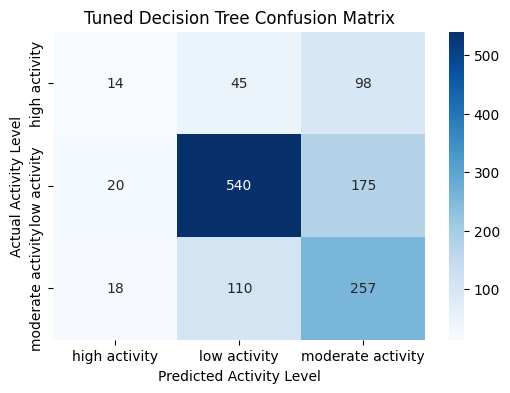

In [11]:
# =========================
# CONFUSION MATRIX FOR TUNED DECISION TREE
# =========================

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_best_dt)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=best_dt_model.classes_,
    yticklabels=best_dt_model.classes_
)

plt.title("Tuned Decision Tree Confusion Matrix")
plt.xlabel("Predicted Activity Level")
plt.ylabel("Actual Activity Level")
plt.show()

In [12]:
# =========================
# FEATURE IMPORTANCE FOR TUNED DECISION TREE
# =========================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_dt_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(10))

,Feature,Importance
6,METALOXIDESENSOR_UNIT3,0.475092
5,METALOXIDESENSOR_UNIT2,0.103818
0,TEMPERATURE,0.075356
3,CO2_ELECTROCHEMICALSENSOR,0.075192
2,CO2_INFRAREDSENSOR,0.068477
4,METALOXIDESENSOR_UNIT1,0.057205
7,METALOXIDESENSOR_UNIT4,0.056398
1,HUMIDITY,0.041062
22,AMBIENT_LIGHT_LEVEL_bright,0.008218
9,TIME_OF_DAY_evening,0.006353


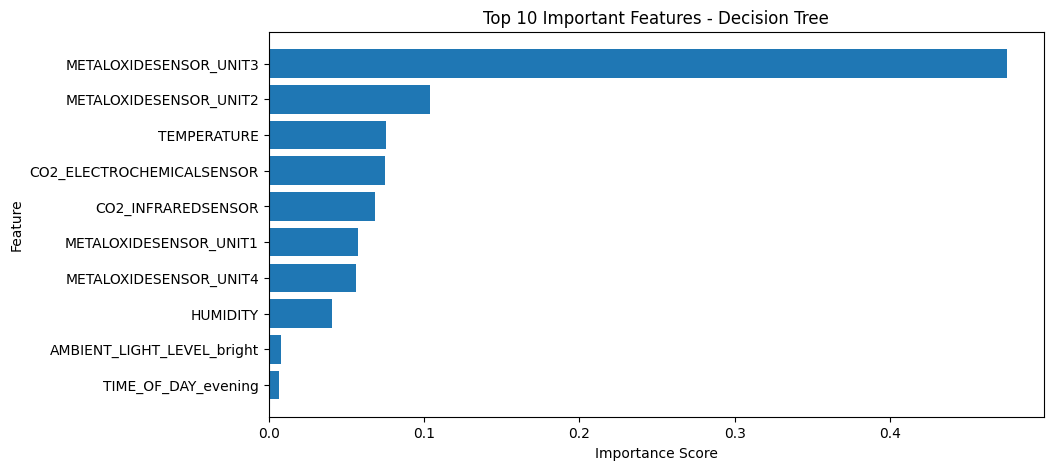

In [13]:
# =========================
# FEATURE IMPORTANCE BAR CHART
# =========================

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

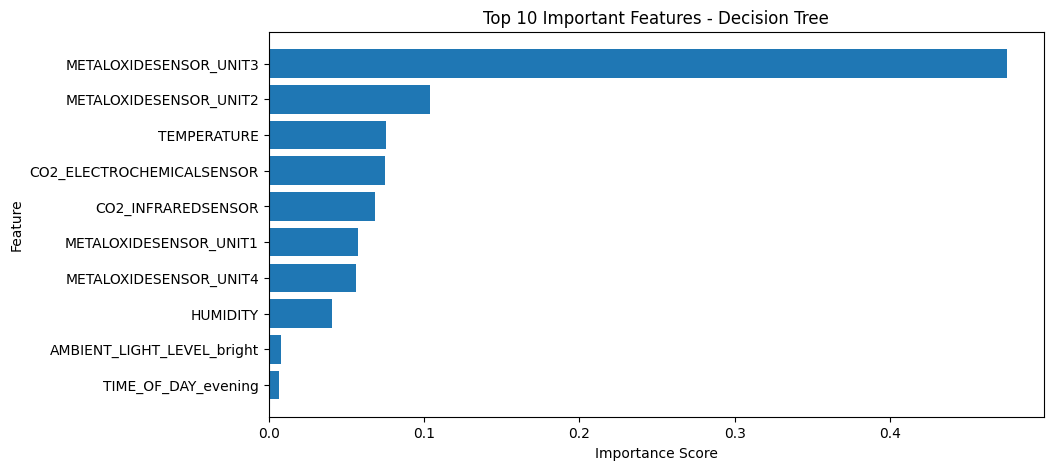

In [14]:
# =========================
# FEATURE IMPORTANCE BAR CHART
# =========================

top_features = feature_importance.head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()